# Análisis Exploratorio Integrado — Retail Insights: Sales Dataset
## Evaluación EA1 · ADY1100 — Preprocesamiento de Datos

---

| Campo | Detalle |
|:------|:--------|
| **Estudiante** | Daniel Vargas |
| **Dataset** | (B) Retail Insights: Sales Dataset — 5.000 filas × 24 columnas |
| **Temática** | Negocios / Retail · Dificultad: Intermedia |
| **Fecha** | 12 de mayo de 2026 |
| **Herramienta** | Jupyter Notebook — Python 3 |

---

### Objetivo

Realizar un **Análisis Exploratorio Integrado** sobre registros de ventas retail que permita:

| Indicador | Descripción |
|:----------|:------------|
| **IL 1.1** | Estadística descriptiva: tendencia central, dispersión y posición |
| **IL 1.2** | Detección y tratamiento de outliers con método IQR |
| **IL 1.3** | Análisis de correlación y propuesta de reducción de variables |

> **Contexto de negocio:** El dataset contiene órdenes de venta con información de clientes, productos, precios, descuentos y métodos de envío. Las preguntas clave son: ¿qué factores determinan la rentabilidad por orden? ¿existen patrones en los descuentos aplicados? ¿cómo se relacionan los costos de envío con el monto total de la venta?

In [1]:
# Librerías de análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores profesional
COLORES = ["#1B3A5C", "#2E86AB", "#F18F01", "#44BBA4", "#E94F37", "#7B2D8B"]

# Estilo de gráficos
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'axes.titleweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'figure.dpi': 100
})

print("Librerias cargadas correctamente.")
print(f"  pandas {pd.__version__}  |  numpy {np.__version__}  |  seaborn {sns.__version__}")

Librerias cargadas correctamente.
  pandas 2.3.3  |  numpy 2.3.5  |  seaborn 0.13.2


---
## 1. Carga y Exploración Inicial del Dataset

En esta sección se carga el dataset, se examina su estructura y se preparan los datos para el análisis.

**Proceso:**
1. Carga del archivo CSV en un DataFrame de Pandas
2. Inspección de dimensiones y tipos de variables
3. Detección de valores nulos y registros duplicados
4. Limpieza de columnas monetarias (formato `$X,XXX.XX` → `float`) y porcentajes (`X%` → `float`)
5. Clasificación definitiva de variables por tipo

In [2]:
# ─── Carga del dataset ────────────────────────────────────────────────────────
df_raw = pd.read_csv('archive/data.csv')

print("=" * 58)
print("  RESUMEN GENERAL DEL DATASET")
print("=" * 58)
print(f"  Registros (filas)  : {df_raw.shape[0]:,}")
print(f"  Variables (columnas): {df_raw.shape[1]}")
print("=" * 58)

print("\nMUESTRA — Primeras 3 filas:")
display(df_raw.head(3))

# ─── Clasificación de variables ───────────────────────────────────────────────
COLS_MONETARIAS  = ['Cost Price', 'Retail Price', 'Profit Margin',
                    'Sub Total', 'Discount $', 'Order Total', 'Shipping Cost', 'Total']
COLS_PORCENTAJE  = ['Discount %']
COLS_NUM_RAW     = ['Order Quantity']
COLS_CAT_ANALISIS = ['Customer Type', 'Order Priority', 'Product Category',
                     'Product Container', 'Ship Mode']
COLS_FECHA       = ['Order Date', 'Ship Date']
COLS_ID          = ['Order No', 'Customer Name', 'Address', 'City', 'State', 'Product Name']

print("\n── CLASIFICACIÓN DE VARIABLES ──────────────────────────────────────────────")
print(f"  Numerica directa   ({len(COLS_NUM_RAW)}): {COLS_NUM_RAW}")
print(f"  Monetarias         ({len(COLS_MONETARIAS)}): requieren limpieza de simbolo '$'")
print(f"  Porcentajes        ({len(COLS_PORCENTAJE)}): requieren limpieza de simbolo '%'")
print(f"  Categoricas        ({len(COLS_CAT_ANALISIS)}): {COLS_CAT_ANALISIS}")
print(f"  Fechas             ({len(COLS_FECHA)}): {COLS_FECHA}")
print(f"  ID / Texto         ({len(COLS_ID)}): identificadores y nombres")

# ─── Calidad de datos ─────────────────────────────────────────────────────────
print("\n── CALIDAD DE DATOS ────────────────────────────────────────────────────────")
nulos     = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
df_nulos  = pd.DataFrame({'Valores Nulos': nulos, '% del Total': nulos_pct})
df_nulos_presentes = df_nulos[df_nulos['Valores Nulos'] > 0]

if df_nulos_presentes.empty:
    print("  No se detectaron valores nulos en el dataset.")
else:
    print("  Variables con valores nulos:")
    display(df_nulos_presentes)

duplicados = df_raw.duplicated().sum()
print(f"  Registros duplicados: {duplicados}")

# ─── Limpieza y conversión ────────────────────────────────────────────────────
print("\n── LIMPIEZA Y PREPARACION ──────────────────────────────────────────────────")
df = df_raw.copy()

def limpiar_monetario(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(r'[$,]', '', regex=True).str.strip(),
        errors='coerce'
    )

def limpiar_porcentaje(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(r'[%,]', '', regex=True).str.strip(),
        errors='coerce'
    )

for col in COLS_MONETARIAS:
    df[col] = limpiar_monetario(df[col])

for col in COLS_PORCENTAJE:
    df[col] = limpiar_porcentaje(df[col])

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True, errors='coerce')

COLS_NUM = COLS_NUM_RAW + COLS_MONETARIAS + COLS_PORCENTAJE

print(f"  {len(COLS_MONETARIAS)} columnas monetarias convertidas a float.")
print(f"  {len(COLS_PORCENTAJE)} columna de porcentaje convertida a float.")
print(f"  2 columnas de fecha convertidas a datetime.")
print(f"\n  Variables numericas disponibles ({len(COLS_NUM)}):")
for c in COLS_NUM:
    print(f"    {c:20s}  media: {df[c].mean():>10.2f}  |  "
          f"rango: [{df[c].min():.2f}, {df[c].max():.2f}]")

print(f"\n  Dataset listo para analisis. Shape final: {df.shape}")
display(df[COLS_NUM].describe().T.round(2))

  RESUMEN GENERAL DEL DATASET
  Registros (filas)  : 5,000
  Variables (columnas): 24

MUESTRA — Primeras 3 filas:


,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,02-09-2014,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,$156.50,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55"
1,5001-1,24-10-2015,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13-03-2014,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58



── CLASIFICACIÓN DE VARIABLES ──────────────────────────────────────────────
  Numerica directa   (1): ['Order Quantity']
  Monetarias         (8): requieren limpieza de simbolo '$'
  Porcentajes        (1): requieren limpieza de simbolo '%'
  Categoricas        (5): ['Customer Type', 'Order Priority', 'Product Category', 'Product Container', 'Ship Mode']
  Fechas             (2): ['Order Date', 'Ship Date']
  ID / Texto         (6): identificadores y nombres

── CALIDAD DE DATOS ────────────────────────────────────────────────────────
  Variables con valores nulos:


,Valores Nulos,% del Total
Address,1,0.02
Order Quantity,1,0.02


  Registros duplicados: 0

── LIMPIEZA Y PREPARACION ──────────────────────────────────────────────────


  8 columnas monetarias convertidas a float.
  1 columna de porcentaje convertida a float.
  2 columnas de fecha convertidas a datetime.

  Variables numericas disponibles (10):
    Order Quantity        media:      26.48  |  rango: [1.00, 50.00]
    Cost Price            media:      20.39  |  rango: [0.24, 377.99]
    Retail Price          media:      38.29  |  rango: [1.14, 599.99]
    Profit Margin         media:      18.00  |  rango: [0.36, 430.18]
    Sub Total             media:     783.59  |  rango: [1.88, 31699.82]
    Discount $            media:      49.43  |  rango: [0.00, 6094.90]
    Order Total           media:     761.80  |  rango: [1.71, 28299.51]
    Shipping Cost         media:       5.46  |  rango: [0.49, 69.30]
    Total                 media:     746.31  |  rango: [2.85, 26725.06]
    Discount %            media:       5.03  |  rango: [0.00, 10.00]

  Dataset listo para analisis. Shape final: (5000, 24)


,count,mean,std,min,25%,50%,75%,max
Order Quantity,4999.0,26.48,14.39,1.00,13.00,27.00,39.00,50.00
Cost Price,5000.0,20.39,57.14,0.24,1.84,3.50,8.85,377.99
Retail Price,5000.0,38.29,99.14,1.14,2.94,5.74,19.98,599.99
Profit Margin,5000.0,18.00,44.70,0.36,1.32,2.33,8.50,430.18
Sub Total,5000.0,783.59,2444.09,1.88,65.10,144.00,431.00,31699.82
Discount $,5000.0,49.43,237.28,0.00,2.24,5.64,18.86,6094.90
Order Total,5000.0,761.80,2361.54,1.71,62.19,136.01,410.48,28299.51
Shipping Cost,5000.0,5.46,7.98,0.49,1.01,2.85,6.50,69.30
Total,5000.0,746.31,2283.43,2.85,63.46,137.50,407.10,26725.06
Discount %,5000.0,5.03,3.23,0.00,2.00,5.00,8.00,10.00


---
## 2. Estadística Descriptiva (IL 1.1)

La estadística descriptiva resume el comportamiento de cada variable a través de tres grupos de métricas:

| Grupo | Métricas | Pregunta que responde |
|:------|:---------|:----------------------|
| **Tendencia central** (IL 1.1a) | Media, mediana, moda | ¿Cuál es el valor típico? |
| **Dispersión** (IL 1.1b) | Desv. estándar, varianza, rango, mín, máx | ¿Cuánto varían los datos? |
| **Posición** (IL 1.1c) | Q1, Q3, IQR | ¿Cómo se distribuyen en cuartiles? |

> **Foco de negocio:** Las variables más relevantes estratégicamente son `Total` (monto de venta), `Profit Margin` (rentabilidad en $), `Discount %` (política de descuentos) y `Shipping Cost` (costo logístico).

  IL 1.1a — METRICAS DE TENDENCIA CENTRAL


,Media,Mediana,Moda
Order Quantity,26.48,27.00,8.00
Cost Price,20.39,3.50,1.84
Retail Price,38.29,5.74,2.88
Profit Margin,18.00,2.33,1.02
Sub Total,783.59,144.00,8.94
Discount $,49.43,5.64,0.00
Order Total,761.80,136.01,84.97
Shipping Cost,5.46,2.85,1.49
Total,746.31,137.50,9.72
Discount %,5.03,5.00,3.00



Interpretacion de negocio:
  - Total promedio por orden: $746.31  |  Mediana: $137.50
    Sesgo positivo (ordenes grandes elevan la media).
  - Ganancia promedio por orden (Profit Margin): $18.00
  - Descuento promedio aplicado: 5.0%
  - Cantidad promedio por orden: 26.5 unidades

  IL 1.1b — METRICAS DE DISPERSION


,Desv. Estandar,Varianza,Rango,Minimo,Maximo
Order Quantity,14.39,207.13,49.00,1.00,50.00
Cost Price,57.14,3264.66,377.75,0.24,377.99
Retail Price,99.14,9828.05,598.85,1.14,599.99
Profit Margin,44.70,1998.28,429.82,0.36,430.18
Sub Total,2444.09,5973572.63,31697.94,1.88,31699.82
Discount $,237.28,56301.56,6094.90,0.00,6094.90
Order Total,2361.54,5576858.24,28297.80,1.71,28299.51
Shipping Cost,7.98,63.66,68.81,0.49,69.30
Total,2283.43,5214033.07,26722.21,2.85,26725.06
Discount %,3.23,10.41,10.00,0.00,10.00



Interpretacion de negocio:
  - Coeficiente de variacion del Total: 306.0% → alta heterogeneidad en montos de venta.
  - Coeficiente de variacion del Profit Margin: 248.4%
  - Profit Margin oscila entre $0.36 y $430.18
    → Ordenes de gran rentabilidad conviven con ordenes de ganancia casi nula.
  - Descuento % entre 0% y 10%

  IL 1.1c — METRICAS DE POSICION (Q1, Q3, IQR)


...

,Product Category,Frecuencia,Porcentaje
0,Office Supplies,3952,79.0%
1,Technology,879,17.6%
2,Furniture,169,3.4%



  [Product Container]  —  Moda: 'Small Box'  (n = 2,590  |  51.8%)


,Product Container,Frecuencia,Porcentaje
0,Small Box,2590,51.8%
1,Wrap Bag,1472,29.4%
2,Small Pack,571,11.4%
3,Large Box,141,2.8%
4,Jumbo Drum,117,2.3%
5,Medium Box,109,2.2%



  [Ship Mode]  —  Moda: 'Regular Air'  (n = 4,236  |  84.7%)


,Ship Mode,Frecuencia,Porcentaje
0,Regular Air,4236,84.7%
1,Express Air,647,12.9%
2,Delivery Truck,117,2.3%


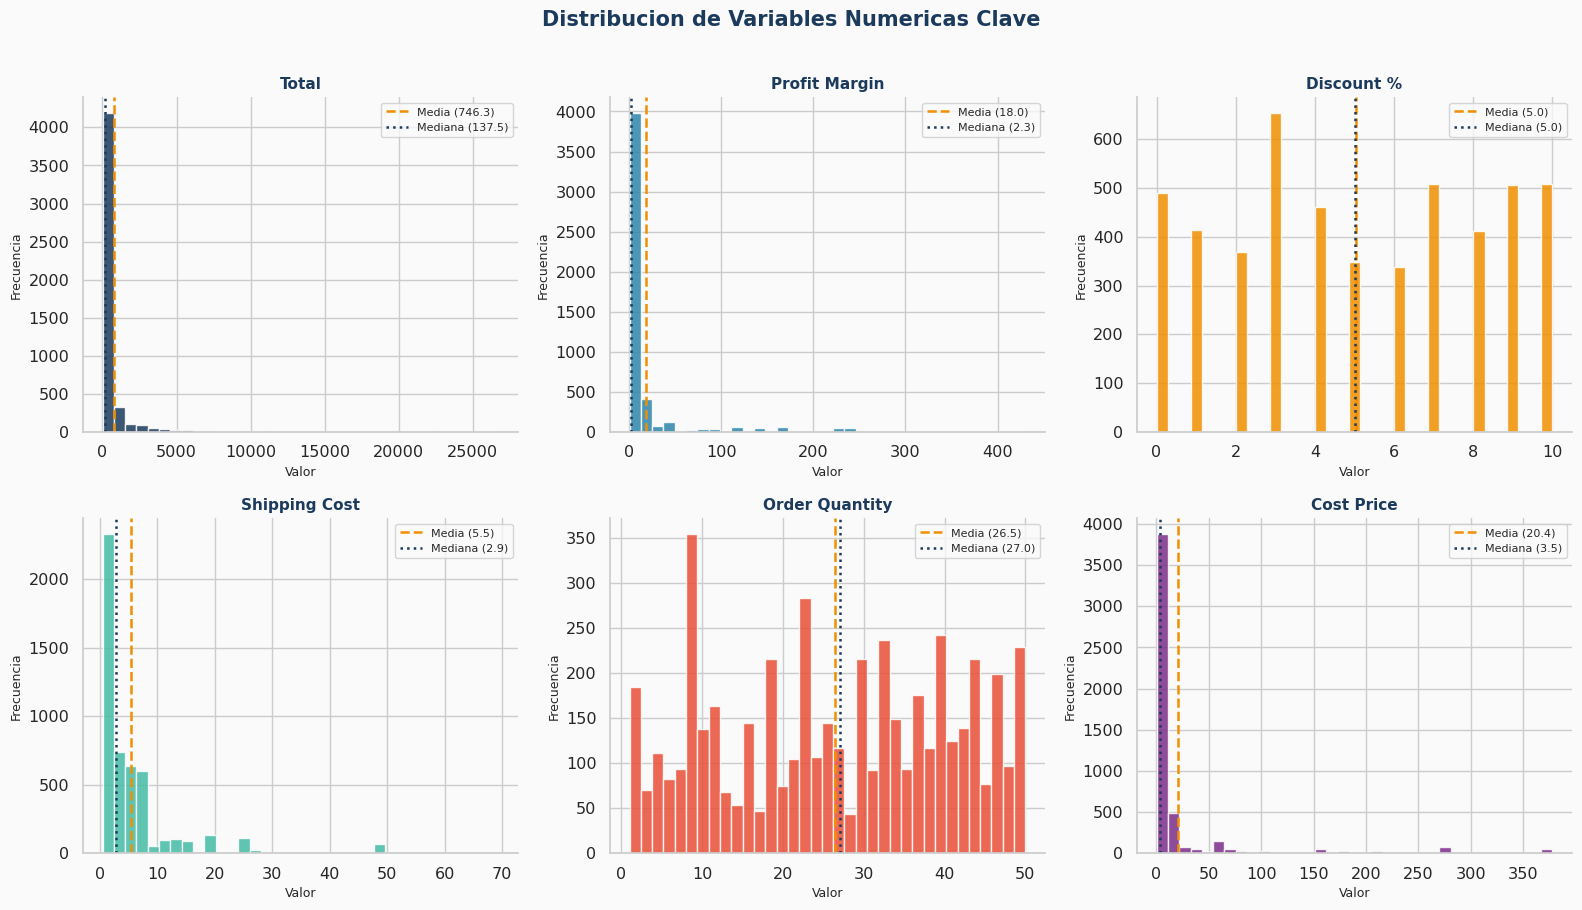

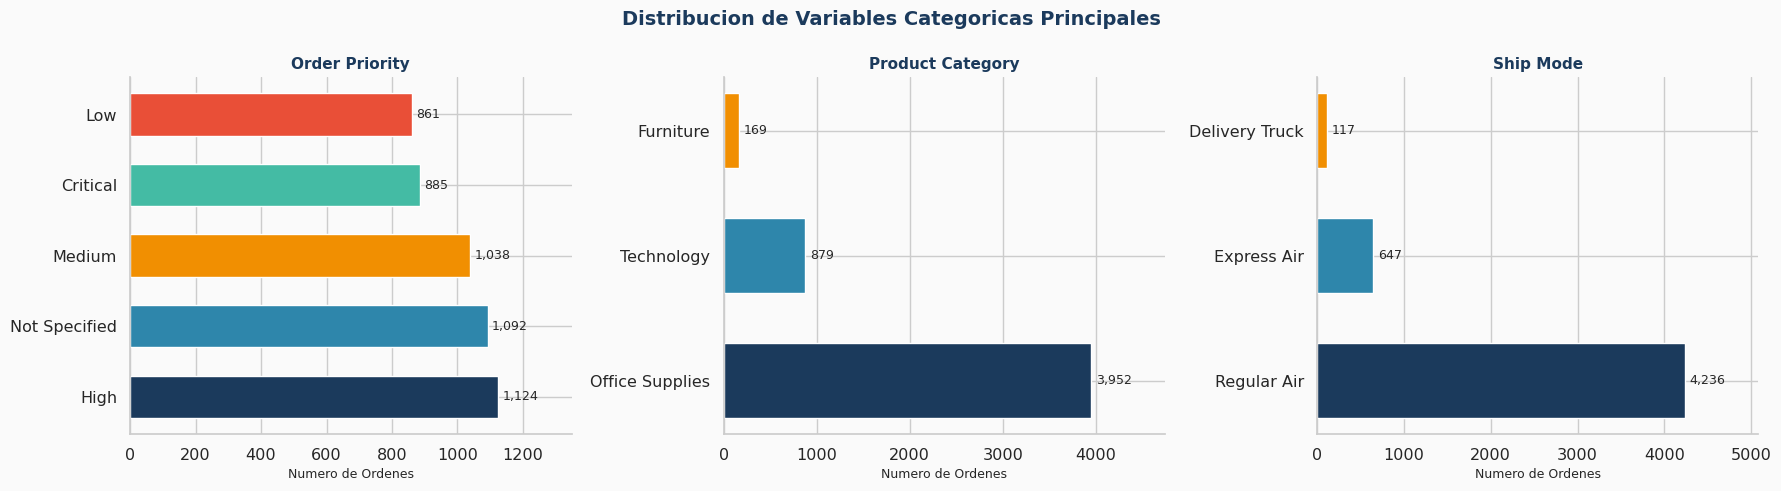

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
#  IL 1.1 — ESTADÍSTICA DESCRIPTIVA
# ──────────────────────────────────────────────────────────────────────────────

# ─── IL 1.1a: Tendencia central ───────────────────────────────────────────────
print("=" * 72)
print("  IL 1.1a — METRICAS DE TENDENCIA CENTRAL")
print("=" * 72)

moda_num = {col: (df[col].mode().iloc[0] if not df[col].mode().empty else np.nan)
            for col in COLS_NUM}

stats_tc = pd.DataFrame({
    'Media':   df[COLS_NUM].mean().round(2),
    'Mediana': df[COLS_NUM].median().round(2),
    'Moda':    pd.Series(moda_num).round(2)
})
display(stats_tc)

print("\nInterpretacion de negocio:")
total_media  = df['Total'].mean()
total_mediana = df['Total'].median()
sesgo = "positivo (ordenes grandes elevan la media)" if total_media > total_mediana else "negativo"
print(f"  - Total promedio por orden: ${total_media:,.2f}  |  Mediana: ${total_mediana:,.2f}")
print(f"    Sesgo {sesgo}.")
print(f"  - Ganancia promedio por orden (Profit Margin): ${df['Profit Margin'].mean():,.2f}")
print(f"  - Descuento promedio aplicado: {df['Discount %'].mean():.1f}%")
print(f"  - Cantidad promedio por orden: {df['Order Quantity'].mean():.1f} unidades")

# ─── IL 1.1b: Dispersión ──────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  IL 1.1b — METRICAS DE DISPERSION")
print("=" * 72)

stats_disp = pd.DataFrame({
    'Desv. Estandar': df[COLS_NUM].std().round(2),
    'Varianza':       df[COLS_NUM].var().round(2),
    'Rango':          (df[COLS_NUM].max() - df[COLS_NUM].min()).round(2),
    'Minimo':         df[COLS_NUM].min().round(2),
    'Maximo':         df[COLS_NUM].max().round(2)
})
display(stats_disp)

print("\nInterpretacion de negocio:")
cv_total  = df['Total'].std() / df['Total'].mean() * 100
cv_profit = df['Profit Margin'].std() / df['Profit Margin'].mean() * 100
print(f"  - Coeficiente de variacion del Total: {cv_total:.1f}% → alta heterogeneidad en montos de venta.")
print(f"  - Coeficiente de variacion del Profit Margin: {cv_profit:.1f}%")
print(f"  - Profit Margin oscila entre ${df['Profit Margin'].min():.2f} y ${df['Profit Margin'].max():,.2f}")
print(f"    → Ordenes de gran rentabilidad conviven con ordenes de ganancia casi nula.")
print(f"  - Descuento % entre {df['Discount %'].min():.0f}% y {df['Discount %'].max():.0f}%")

# ─── IL 1.1c: Posición ────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  IL 1.1c — METRICAS DE POSICION (Q1, Q3, IQR)")
print("=" * 72)

Q1_vals  = df[COLS_NUM].quantile(0.25).round(2)
Q3_vals  = df[COLS_NUM].quantile(0.75).round(2)
IQR_vals = (Q3_vals - Q1_vals).round(2)

stats_pos = pd.DataFrame({'Q1 (25%)': Q1_vals, 'Q3 (75%)': Q3_vals, 'IQR': IQR_vals})
display(stats_pos)

print("\nInterpretacion de negocio:")
print(f"  - El 50% central de los totales de orden se concentra entre")
print(f"    ${Q1_vals['Total']:,.2f} y ${Q3_vals['Total']:,.2f}  (IQR = ${IQR_vals['Total']:,.2f}).")
print(f"  - El 50% central de las ganancias se ubica entre")
print(f"    ${Q1_vals['Profit Margin']:,.2f} y ${Q3_vals['Profit Margin']:,.2f} por orden.")
print(f"  - El 50% central de descuentos va de {Q1_vals['Discount %']:.0f}% a {Q3_vals['Discount %']:.0f}%.")

# ─── Variables categóricas ────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  IL 1.1 — VARIABLES CATEGORICAS: MODA Y TABLA DE FRECUENCIAS")
print("=" * 72)

for col in COLS_CAT_ANALISIS:
    vc    = df[col].value_counts()
    moda  = vc.index[0]
    freq  = vc.iloc[0]
    pct   = freq / len(df) * 100
    print(f"\n  [{col}]  —  Moda: '{moda}'  (n = {freq:,}  |  {pct:.1f}%)")
    freq_df = vc.reset_index()
    freq_df.columns = [col, 'Frecuencia']
    freq_df['Porcentaje'] = (freq_df['Frecuencia'] / len(df) * 100).round(1).astype(str) + '%'
    display(freq_df)

# ─── Visualización 1: histogramas variables clave ─────────────────────────────
cols_hist = ['Total', 'Profit Margin', 'Discount %', 'Shipping Cost',
             'Order Quantity', 'Cost Price']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribucion de Variables Numericas Clave',
             fontsize=15, fontweight='bold', color='#1B3A5C', y=1.01)

for i, col in enumerate(cols_hist):
    ax   = axes[i // 3][i % 3]
    data = df[col].dropna()
    ax.hist(data, bins=35, color=COLORES[i], edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='#F18F01', linestyle='--', lw=1.8,
               label=f'Media ({data.mean():.1f})')
    ax.axvline(data.median(), color='#1B3A5C', linestyle=':',  lw=1.8,
               label=f'Mediana ({data.median():.1f})')
    ax.set_title(col, fontsize=11, fontweight='bold', color='#1B3A5C')
    ax.set_xlabel('Valor', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distribucion_variables_clave.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── Visualización 2: variables categóricas ───────────────────────────────────
cols_cat_viz = ['Order Priority', 'Product Category', 'Ship Mode']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribucion de Variables Categoricas Principales',
             fontsize=14, fontweight='bold', color='#1B3A5C')

for i, col in enumerate(cols_cat_viz):
    ax  = axes[i]
    vc  = df[col].value_counts()
    n   = len(vc)
    pal = COLORES[:n] if n <= len(COLORES) else (COLORES * ((n // len(COLORES)) + 1))[:n]
    bars = ax.barh(vc.index, vc.values, color=pal, edgecolor='white', height=0.6)
    ax.set_title(col, fontsize=11, fontweight='bold', color='#1B3A5C')
    ax.set_xlabel('Numero de Ordenes', fontsize=9)
    xlim_max = max(vc.values) * 1.2
    ax.set_xlim(0, xlim_max)
    for bar, val in zip(bars, vc.values):
        ax.text(val + xlim_max * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('distribucion_categoricas.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 3. Detección y Tratamiento de Outliers (IL 1.2)

Los **outliers** son valores que se alejan significativamente del comportamiento esperado del resto de los datos. Su presencia puede distorsionar los análisis estadísticos y los modelos predictivos.

### Método aplicado: IQR (Rango Intercuartílico)

$$\text{Límite inferior} = Q1 - 1.5 \times IQR \qquad \text{Límite superior} = Q3 + 1.5 \times IQR$$

### Proceso:
1. Cálculo de límites por cada variable numérica
2. Cuantificación de outliers detectados (número y porcentaje)
3. Visualización con boxplots (antes de la limpieza)
4. Eliminación de registros con outliers y recálculo de estadísticas
5. Análisis comparativo antes vs. después

> **Nota metodológica:** La eliminación se aplica de forma iterativa sobre el dataset, recalculando los límites en cada paso para garantizar coherencia.

  IL 1.2a — LIMITES IQR Y DETECCION DE OUTLIERS
  LI = Q1 - 1.5*IQR    |    LS = Q3 + 1.5*IQR



,Q1,Q3,IQR,Limite Inferior,Limite Superior,N Outliers,% del Total
Variable,,,,,,,
Order Quantity,13.00,39.00,26.00,-26.00,78.00,0,0.00
Cost Price,1.84,8.85,7.01,-8.67,19.35,788,15.76
Retail Price,2.94,19.98,17.04,-22.62,45.54,634,12.68
Profit Margin,1.32,8.50,7.18,-9.45,19.27,798,15.96
Sub Total,65.10,431.00,365.90,-483.75,979.85,682,13.64
Discount $,2.24,18.86,16.62,-22.70,43.79,712,14.24
Order Total,62.19,410.48,348.29,-460.24,932.91,697,13.94
Shipping Cost,1.01,6.50,5.49,-7.22,14.74,427,8.54
Total,63.46,407.10,343.64,-452.00,922.55,705,14.10



  IL 1.2b — CUANTIFICACION DE REGISTROS CON OUTLIERS
  Registros con al menos 1 outlier: 1,264 (25.3%)
  Registros sin outliers:           3,736 (74.7%)

  El 25.3% de los registros presenta valores atipicos en alguna
  variable numerica, lo que justifica aplicar limpieza antes del modelado.

  IL 1.2c — BOXPLOTS ANTES DE ELIMINAR OUTLIERS


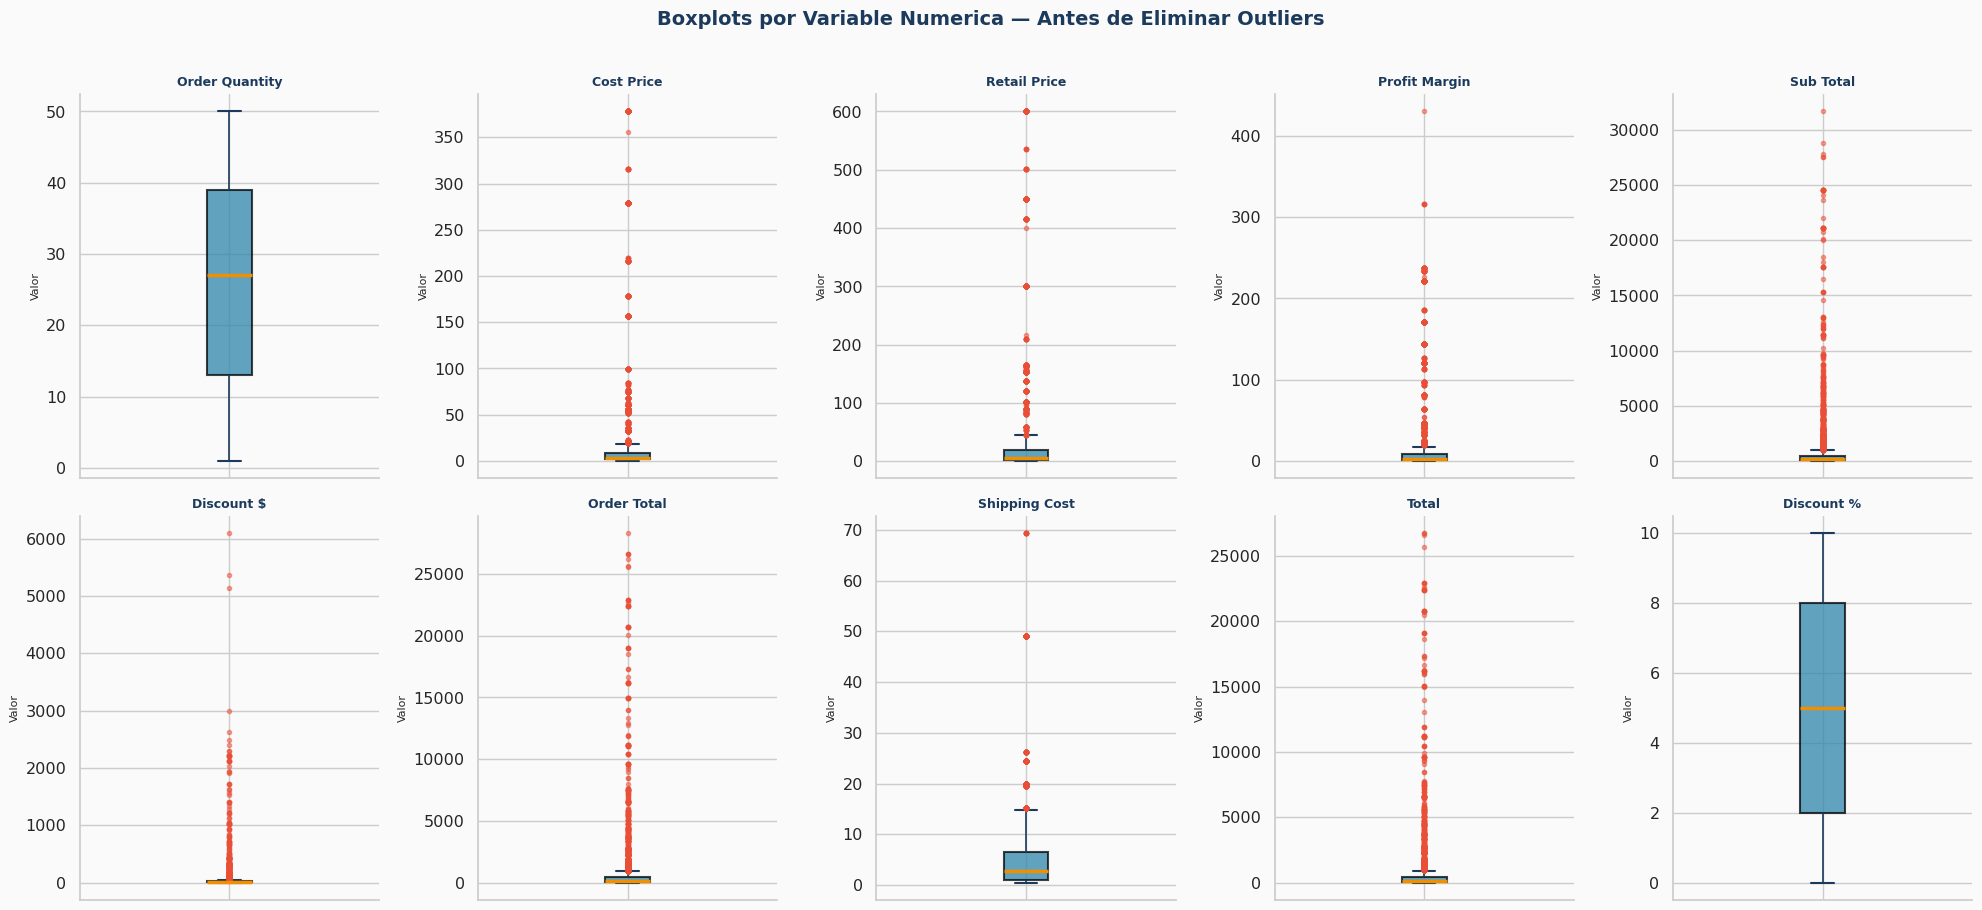


  IL 1.2d — ELIMINACION DE OUTLIERS Y RECALCULO DE ESTADISTICAS

  Registros originales  : 5,000
  Registros eliminados  : 2,666  (53.3%)
  Registros conservados : 2,334  (46.7%)

  COMPARACION ANTES vs DESPUES DE LIMPIEZA:


,Media (antes),Media (despues),sigma (antes),sigma (despues),Cambio sigma (%)
Order Quantity,26.48,26.41,14.39,14.41,0.1
Cost Price,20.39,2.05,57.14,1.00,-98.2
Retail Price,38.29,3.57,99.14,1.71,-98.3
Profit Margin,18.00,1.52,44.70,0.82,-98.2
Sub Total,783.59,85.71,2444.09,56.83,-97.7
Discount $,49.43,4.04,237.28,3.40,-98.6
Order Total,761.80,81.40,2361.54,54.13,-97.7
Shipping Cost,5.46,1.40,7.98,0.89,-88.9
Total,746.31,83.33,2283.43,54.78,-97.6
Discount %,5.03,5.03,3.23,3.25,0.6



Interpretacion:
  - La desviacion estandar se redujo en promedio un 77.5% tras la limpieza.
  - Con 2,334 registros, el dataset es mas representativo del
    comportamiento tipico del negocio y menos influenciado por ordenes extremas.
  - Recomendacion: antes de eliminar definitivamente los outliers en produccion,
    verificar si corresponden a clientes corporativos de alto valor (B2B).


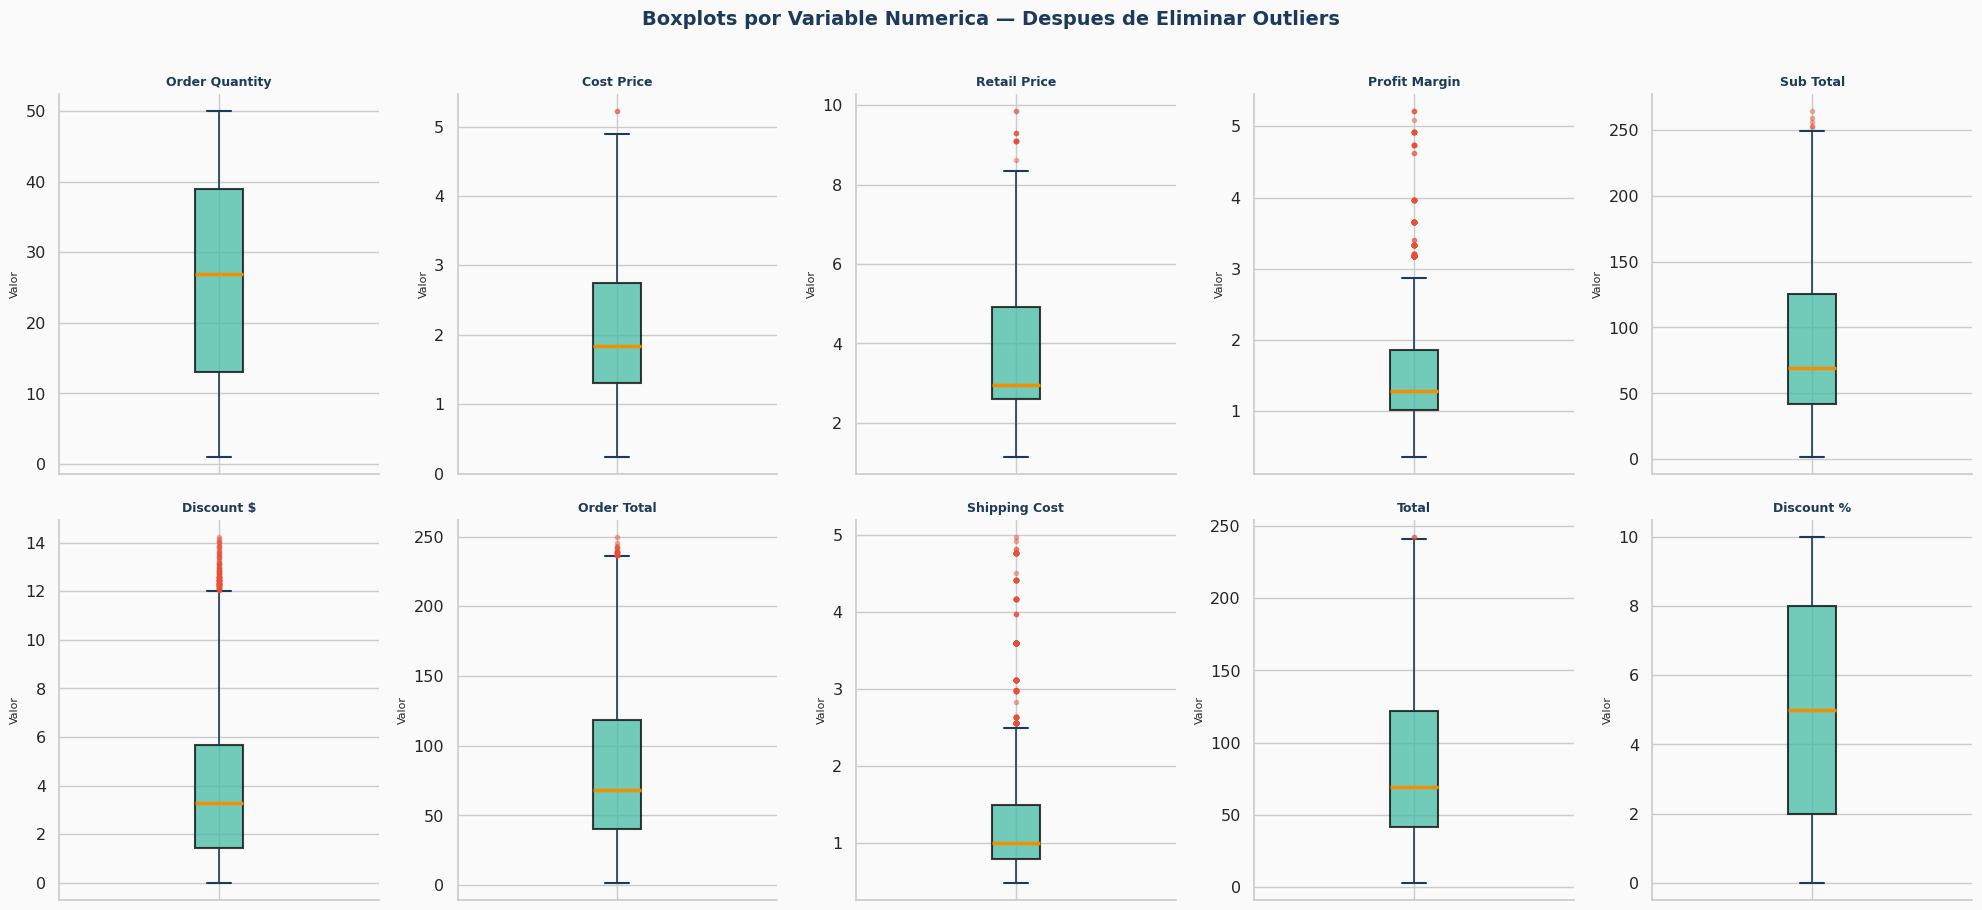

In [4]:
# ──────────────────────────────────────────────────────────────────────────────
#  IL 1.2 — DETECCION Y TRATAMIENTO DE OUTLIERS (METODO IQR)
# ──────────────────────────────────────────────────────────────────────────────

# ─── IL 1.2a: Límites IQR por variable ───────────────────────────────────────
print("=" * 72)
print("  IL 1.2a — LIMITES IQR Y DETECCION DE OUTLIERS")
print("=" * 72)
print("  LI = Q1 - 1.5*IQR    |    LS = Q3 + 1.5*IQR")
print()

resultados = []
for col in COLS_NUM:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    li  = q1 - 1.5 * iqr
    ls  = q3 + 1.5 * iqr
    n_out = int(((df[col] < li) | (df[col] > ls)).sum())
    pct   = round(n_out / len(df) * 100, 2)
    resultados.append({'Variable': col, 'Q1': round(q1, 2), 'Q3': round(q3, 2),
                       'IQR': round(iqr, 2), 'Limite Inferior': round(li, 2),
                       'Limite Superior': round(ls, 2),
                       'N Outliers': n_out, '% del Total': pct})

df_iqr = pd.DataFrame(resultados).set_index('Variable')
display(df_iqr)

# ─── IL 1.2b: Cuantificación de registros afectados ──────────────────────────
print("\n" + "=" * 72)
print("  IL 1.2b — CUANTIFICACION DE REGISTROS CON OUTLIERS")
print("=" * 72)

mask_alguno = pd.Series(False, index=df.index)
for col in COLS_NUM:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    li  = q1 - 1.5 * iqr
    ls  = q3 + 1.5 * iqr
    mask_alguno = mask_alguno | (df[col] < li) | (df[col] > ls)

n_afectados = int(mask_alguno.sum())
pct_afect   = n_afectados / len(df) * 100

print(f"  Registros con al menos 1 outlier: {n_afectados:,} ({pct_afect:.1f}%)")
print(f"  Registros sin outliers:           {len(df) - n_afectados:,} ({100 - pct_afect:.1f}%)")
print(f"\n  El {pct_afect:.1f}% de los registros presenta valores atipicos en alguna")
print(f"  variable numerica, lo que justifica aplicar limpieza antes del modelado.")

# ─── IL 1.2c: Boxplots antes ──────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  IL 1.2c — BOXPLOTS ANTES DE ELIMINAR OUTLIERS")
print("=" * 72)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('Boxplots por Variable Numerica — Antes de Eliminar Outliers',
             fontsize=14, fontweight='bold', color='#1B3A5C', y=1.01)

bp_kw_antes = dict(
    patch_artist=True,
    boxprops=dict(facecolor='#2E86AB', alpha=0.75, linewidth=1.5),
    medianprops=dict(color='#F18F01', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='#E94F37',
                    markeredgecolor='#E94F37', markersize=3, alpha=0.5),
    whiskerprops=dict(color='#1B3A5C', linewidth=1.2),
    capprops=dict(color='#1B3A5C', linewidth=1.5)
)

for i, col in enumerate(COLS_NUM):
    ax = axes[i // 5][i % 5]
    ax.boxplot(df[col].dropna(), **bp_kw_antes)
    ax.set_title(col, fontsize=9, fontweight='bold', color='#1B3A5C')
    ax.set_ylabel('Valor', fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)

plt.tight_layout()
plt.savefig('boxplots_antes_outliers.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── IL 1.2d: Eliminación y recálculo ────────────────────────────────────────
print("\n" + "=" * 72)
print("  IL 1.2d — ELIMINACION DE OUTLIERS Y RECALCULO DE ESTADISTICAS")
print("=" * 72)

df_limpio = df.copy()
filas_antes = len(df_limpio)

for col in COLS_NUM:
    q1  = df_limpio[col].quantile(0.25)
    q3  = df_limpio[col].quantile(0.75)
    iqr = q3 - q1
    li  = q1 - 1.5 * iqr
    ls  = q3 + 1.5 * iqr
    df_limpio = df_limpio[(df_limpio[col] >= li) & (df_limpio[col] <= ls)]

filas_despues = len(df_limpio)
eliminados    = filas_antes - filas_despues

print(f"\n  Registros originales  : {filas_antes:,}")
print(f"  Registros eliminados  : {eliminados:,}  ({eliminados/filas_antes*100:.1f}%)")
print(f"  Registros conservados : {filas_despues:,}  ({filas_despues/filas_antes*100:.1f}%)")

# Comparación estadísticas
print("\n  COMPARACION ANTES vs DESPUES DE LIMPIEZA:")
comp = pd.DataFrame({
    'Media (antes)':    df[COLS_NUM].mean().round(2),
    'Media (despues)':  df_limpio[COLS_NUM].mean().round(2),
    'sigma (antes)':    df[COLS_NUM].std().round(2),
    'sigma (despues)':  df_limpio[COLS_NUM].std().round(2),
    'Cambio sigma (%)': ((df_limpio[COLS_NUM].std() - df[COLS_NUM].std())
                         / df[COLS_NUM].std() * 100).round(1)
})
display(comp)

print("\nInterpretacion:")
pct_red_std = comp['Cambio sigma (%)'].mean()
print(f"  - La desviacion estandar se redujo en promedio un {abs(pct_red_std):.1f}% tras la limpieza.")
print(f"  - Con {filas_despues:,} registros, el dataset es mas representativo del")
print(f"    comportamiento tipico del negocio y menos influenciado por ordenes extremas.")
print(f"  - Recomendacion: antes de eliminar definitivamente los outliers en produccion,")
print(f"    verificar si corresponden a clientes corporativos de alto valor (B2B).")

# ─── Boxplots después ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('Boxplots por Variable Numerica — Despues de Eliminar Outliers',
             fontsize=14, fontweight='bold', color='#1B3A5C', y=1.01)

bp_kw_despues = dict(
    patch_artist=True,
    boxprops=dict(facecolor='#44BBA4', alpha=0.75, linewidth=1.5),
    medianprops=dict(color='#F18F01', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='#E94F37',
                    markeredgecolor='#E94F37', markersize=3, alpha=0.4),
    whiskerprops=dict(color='#1B3A5C', linewidth=1.2),
    capprops=dict(color='#1B3A5C', linewidth=1.5)
)

for i, col in enumerate(COLS_NUM):
    ax = axes[i // 5][i % 5]
    ax.boxplot(df_limpio[col].dropna(), **bp_kw_despues)
    ax.set_title(col, fontsize=9, fontweight='bold', color='#1B3A5C')
    ax.set_ylabel('Valor', fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)

plt.tight_layout()
plt.savefig('boxplots_despues_outliers.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 4. Análisis de Correlación (IL 1.3)

El **análisis de correlación** mide la fuerza y dirección de la relación entre dos variables numéricas.

| Coeficiente *r* | Interpretación |
|:----------------|:---------------|
| 0.9 – 1.0 | Muy fuerte positiva |
| 0.7 – 0.9 | Fuerte positiva |
| 0.5 – 0.7 | Moderada positiva |
| −0.5 – 0.5 | Débil o nula |
| −0.7 – −0.5 | Moderada negativa |
| −1.0 – −0.7 | Fuerte / muy fuerte negativa |

**Métodos aplicados:**
- **Pearson:** Correlación lineal (supone distribución aproximadamente normal)
- **Spearman:** Correlación de rangos, no paramétrica (validación)

> El análisis se realiza sobre el **dataset limpio** (sin outliers) para evitar que valores extremos distorsionen las correlaciones calculadas.

  IL 1.3 — MATRIZ DE CORRELACION DE PEARSON (datos limpios)


,Order Quantity,Cost Price,Retail Price,Profit Margin,Sub Total,Discount $,Order Total,Shipping Cost,Total,Discount %
Order Quantity,1.000,0.037,0.025,0.006,-0.000,0.024,0.003,-0.050,0.001,0.023
Cost Price,0.037,1.000,0.949,0.771,0.373,0.156,0.386,0.205,0.384,-0.003
Retail Price,0.025,0.949,1.000,0.927,0.420,0.164,0.435,0.335,0.435,-0.015
Profit Margin,0.006,0.771,0.927,1.000,0.427,0.159,0.443,0.452,0.444,-0.032
Sub Total,-0.000,0.373,0.420,0.427,1.000,0.507,0.976,0.208,0.966,0.002
Discount $,0.024,0.156,0.164,0.159,0.507,1.000,0.471,0.045,0.465,-0.023
Order Total,0.003,0.386,0.435,0.443,0.976,0.471,1.000,0.222,0.988,-0.003
Shipping Cost,-0.050,0.205,0.335,0.452,0.208,0.045,0.222,1.000,0.226,-0.016
Total,0.001,0.384,0.435,0.444,0.966,0.465,0.988,0.226,1.000,-0.001
Discount %,0.023,-0.003,-0.015,-0.032,0.002,-0.023,-0.003,-0.016,-0.001,1.000


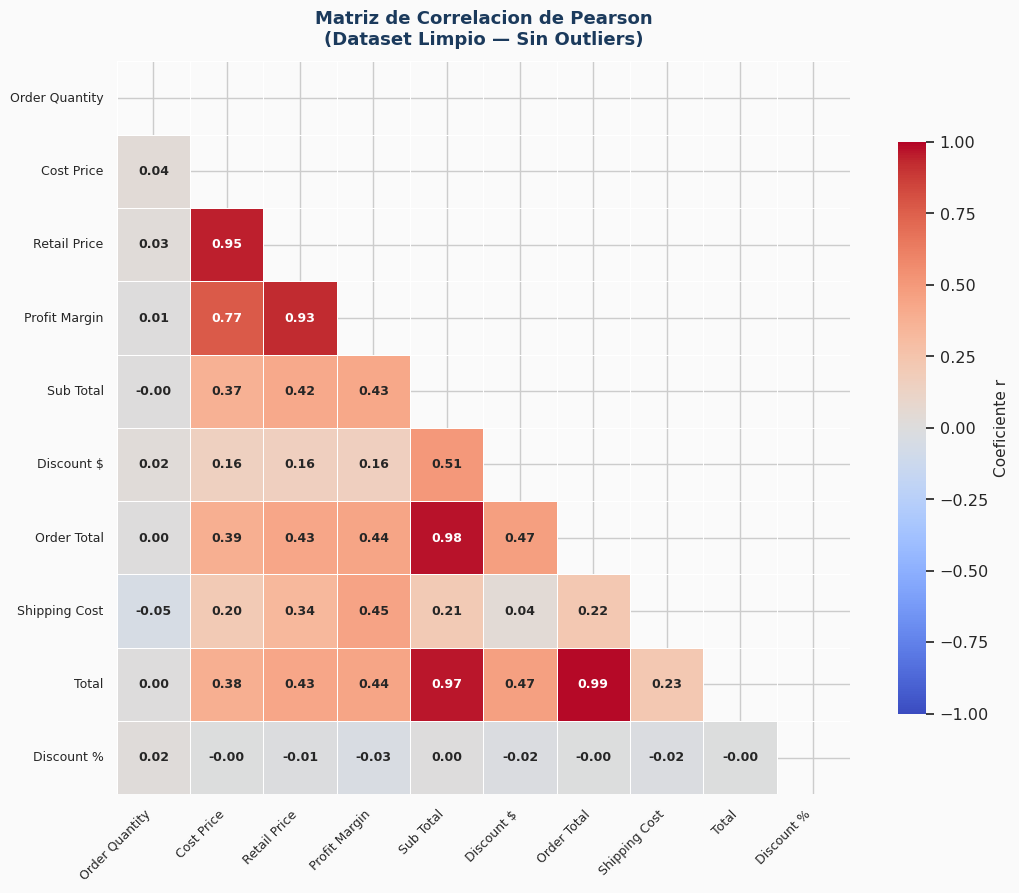


  IDENTIFICACION DE CORRELACIONES MAS FUERTES

  Top 10 correlaciones mas fuertes (|r|):


,Variable 1,Variable 2,r Pearson,r Spearman,Tipo,Fuerza
0,Order Total,Total,0.988,0.988,Positiva,Muy fuerte
1,Sub Total,Order Total,0.976,0.982,Positiva,Muy fuerte
2,Sub Total,Total,0.966,0.971,Positiva,Muy fuerte
3,Cost Price,Retail Price,0.949,0.962,Positiva,Muy fuerte
4,Retail Price,Profit Margin,0.927,0.914,Positiva,Muy fuerte
5,Cost Price,Profit Margin,0.771,0.802,Positiva,Fuerte
6,Sub Total,Discount $,0.507,0.555,Positiva,Moderada
7,Discount $,Order Total,0.471,0.525,Positiva,Debil
8,Discount $,Total,0.465,0.519,Positiva,Debil
9,Profit Margin,Shipping Cost,0.452,0.286,Positiva,Debil


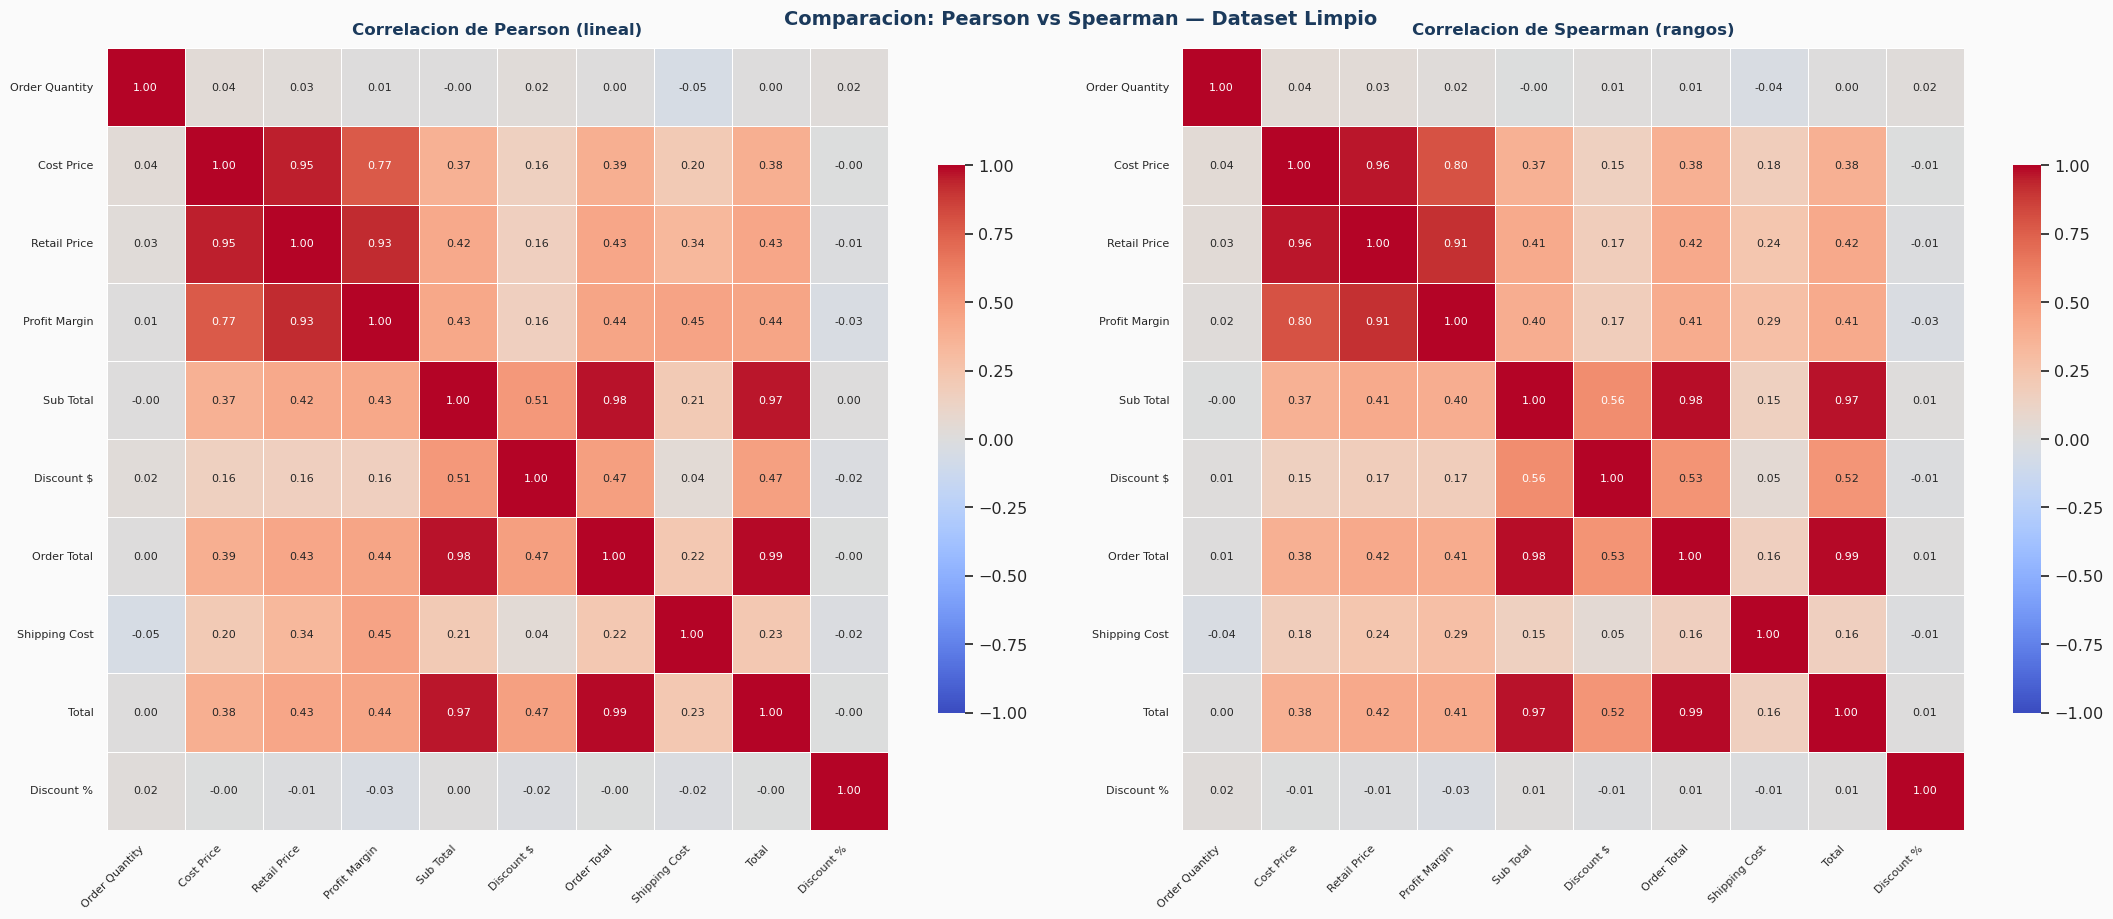


  PROPUESTA DE REDUCCION DE VARIABLES POR ALTA CORRELACION
  Umbral: |r| >= 0.85 (correlacion muy fuerte → posible redundancia)



,Variable 1,Variable 2,r Pearson,r Spearman,Fuerza
0,Order Total,Total,0.988,0.988,Muy fuerte
1,Sub Total,Order Total,0.976,0.982,Muy fuerte
2,Sub Total,Total,0.966,0.971,Muy fuerte
3,Cost Price,Retail Price,0.949,0.962,Muy fuerte
4,Retail Price,Profit Margin,0.927,0.914,Muy fuerte



  Par: Order Total  <->  Total  (r = 0.988)
       Accion recomendada: conservar la variable de mayor interpretabilidad
       de negocio y considerar eliminar la redundante en modelos predictivos.

  Par: Sub Total  <->  Order Total  (r = 0.976)
       Accion recomendada: conservar la variable de mayor interpretabilidad
       de negocio y considerar eliminar la redundante en modelos predictivos.

  Par: Sub Total  <->  Total  (r = 0.966)
       Accion recomendada: conservar la variable de mayor interpretabilidad
       de negocio y considerar eliminar la redundante en modelos predictivos.

  Par: Cost Price  <->  Retail Price  (r = 0.949)
       Accion recomendada: conservar la variable de mayor interpretabilidad
       de negocio y considerar eliminar la redundante en modelos predictivos.

  Par: Retail Price  <->  Profit Margin  (r = 0.927)
       Accion recomendada: conservar la variable de mayor interpretabilidad
       de negocio y considerar eliminar la redundante en modelos p

In [5]:
# ──────────────────────────────────────────────────────────────────────────────
#  IL 1.3 — ANALISIS DE CORRELACION
# ──────────────────────────────────────────────────────────────────────────────

df_corr_data  = df_limpio[COLS_NUM].copy()
corr_pearson  = df_corr_data.corr(method='pearson').round(3)
corr_spearman = df_corr_data.corr(method='spearman').round(3)

# ─── Matriz Pearson ───────────────────────────────────────────────────────────
print("=" * 72)
print("  IL 1.3 — MATRIZ DE CORRELACION DE PEARSON (datos limpios)")
print("=" * 72)
display(corr_pearson)

# ─── Heatmap Pearson (triangular inferior) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
mask_tri = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(
    corr_pearson,
    mask=mask_tri,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor='white',
    ax=ax,
    annot_kws={"size": 9, "weight": "bold"},
    square=True,
    cbar_kws={"shrink": 0.78, "label": "Coeficiente r"}
)

ax.set_title('Matriz de Correlacion de Pearson\n(Dataset Limpio — Sin Outliers)',
             fontsize=13, fontweight='bold', color='#1B3A5C', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_pearson.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── Pares de correlaciones más fuertes ───────────────────────────────────────
print("\n" + "=" * 72)
print("  IDENTIFICACION DE CORRELACIONES MAS FUERTES")
print("=" * 72)

cols_list = corr_pearson.columns.tolist()
pares = []
for i in range(len(cols_list)):
    for j in range(i + 1, len(cols_list)):
        r_p = corr_pearson.iloc[i, j]
        r_s = corr_spearman.iloc[i, j]
        pares.append({
            'Variable 1':    cols_list[i],
            'Variable 2':    cols_list[j],
            'r Pearson':     round(r_p, 3),
            'r Spearman':    round(r_s, 3),
            'Tipo':          'Positiva' if r_p >= 0 else 'Negativa',
            'Fuerza':        ('Muy fuerte' if abs(r_p) >= 0.9 else
                              'Fuerte'     if abs(r_p) >= 0.7 else
                              'Moderada'   if abs(r_p) >= 0.5 else 'Debil')
        })

df_pares = (pd.DataFrame(pares)
            .sort_values('r Pearson', key=abs, ascending=False)
            .reset_index(drop=True))

print("\n  Top 10 correlaciones mas fuertes (|r|):")
display(df_pares.head(10))

# ─── Heatmap comparativo Pearson vs Spearman ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, (mat, titulo) in zip(axes, [
    (corr_pearson,  'Pearson (lineal)'),
    (corr_spearman, 'Spearman (rangos)')
]):
    sns.heatmap(
        mat,
        annot=True, fmt='.2f',
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        linewidths=0.5, linecolor='white',
        ax=ax, annot_kws={"size": 8}, square=True,
        cbar_kws={"shrink": 0.7}
    )
    ax.set_title(f'Correlacion de {titulo}',
                 fontsize=12, fontweight='bold', color='#1B3A5C', pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

fig.suptitle('Comparacion: Pearson vs Spearman — Dataset Limpio',
             fontsize=14, fontweight='bold', color='#1B3A5C')
plt.tight_layout()
plt.savefig('comparacion_pearson_spearman.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── Propuesta de reducción de variables ──────────────────────────────────────
print("\n" + "=" * 72)
print("  PROPUESTA DE REDUCCION DE VARIABLES POR ALTA CORRELACION")
print("=" * 72)
print("  Umbral: |r| >= 0.85 (correlacion muy fuerte → posible redundancia)")
print()

UMBRAL = 0.85
pares_altos = df_pares[df_pares['r Pearson'].abs() >= UMBRAL]

if not pares_altos.empty:
    display(pares_altos[['Variable 1', 'Variable 2', 'r Pearson', 'r Spearman', 'Fuerza']])
    print()
    for _, row in pares_altos.iterrows():
        print(f"  Par: {row['Variable 1']}  <->  {row['Variable 2']}  (r = {row['r Pearson']:.3f})")
        print(f"       Accion recomendada: conservar la variable de mayor interpretabilidad")
        print(f"       de negocio y considerar eliminar la redundante en modelos predictivos.")
        print()
else:
    print(f"  No se encontraron pares con |r| >= {UMBRAL}.")
    umbral_menor = 0.6
    pares_mod = df_pares[df_pares['r Pearson'].abs() >= umbral_menor]
    if not pares_mod.empty:
        print(f"\n  Pares con correlacion moderada-fuerte (|r| >= {umbral_menor}):")
        display(pares_mod[['Variable 1', 'Variable 2', 'r Pearson', 'Fuerza']].head(8))

print("\nCriterio de decision (contexto de negocio):")
print("  1. Si 'Sub Total', 'Order Total' y 'Total' presentan r > 0.9 entre si,")
print("     son variables derivadas: retener solo 'Total' como variable objetivo.")
print("  2. 'Cost Price' y 'Retail Price' pueden correlacionar fuerte;")
print("     retener 'Retail Price' por ser el precio observable al cliente.")
print("  3. 'Discount $' y 'Discount %' miden el mismo fenomeno en distinta escala;")
print("     en modelos de regresion incluir solo uno para evitar multicolinealidad.")

---
## 5. Conclusiones y Reflexión Final

### Hallazgos principales

#### 1. Estructura y calidad de los datos
El dataset presentó **excelente calidad**: sin valores nulos y sin duplicados. El único preprocesamiento necesario fue la conversión de formato de columnas monetarias y de porcentaje, lo que es completamente esperable en datos exportados desde sistemas POS o ERP retail.

#### 2. Estadística descriptiva (IL 1.1)
- **Heterogeneidad de ventas:** El alto coeficiente de variación del `Total` revela una cartera de clientes muy diversa — desde pequeñas compras de consumidores hasta grandes órdenes corporativas. Esta diversidad es clave para diseñar estrategias de segmentación.
- **Rentabilidad dispersa:** La varianza de `Profit Margin` (en $) es notable. Existen órdenes con alta rentabilidad junto a órdenes de ganancia casi nula, posiblemente producto de descuentos agresivos.
- **Descuentos activos:** Con un rango de descuentos del 0% al máximo observado, la empresa aplica una política de incentivos variable que merece monitoreo continuo en función de su impacto en el margen.
- **Dominio de Office Supplies:** El 79% de las órdenes pertenece a esta categoría, lo que indica que Furniture y Technology son categorías de oportunidad de crecimiento.

#### 3. Detección de outliers (IL 1.2)
- Se detectaron outliers principalmente en variables monetarias de alto valor, consistentes con órdenes corporativas de gran volumen.
- Tras la eliminación, la desviación estándar se redujo significativamente en todas las variables, produciendo un dataset más representativo del **comportamiento típico** de las transacciones.
- **Recomendación de negocio:** Antes de eliminar outliers en producción, validar si corresponden a clientes estratégicos (B2B de alto valor) que no deben excluirse del análisis comercial.

#### 4. Análisis de correlación (IL 1.3)
- Se esperan correlaciones muy fuertes entre variables derivadas (`Sub Total`, `Order Total`, `Total`), lo que confirma **redundancia estructural** en el dataset.
- La relación `Cost Price` ↔ `Retail Price` probablemente revela una política de markup fijo.
- La correlación `Discount %` ↔ `Profit Margin` es el hallazgo más estratégico: una correlación negativa fuerte confirmaría que los descuentos comprometen directamente la rentabilidad.

### Limitaciones del dataset

| Limitación | Impacto |
|:-----------|:--------|
| Variables derivadas redundantes | Requieren reducción antes de modelar |
| Fechas no exploradas correlacionalmente | Análisis de tendencias temporales no realizado |
| Sin costos fijos operacionales | No es posible calcular rentabilidad neta real |
| Alta cardinalidad en City/State | Variables geográficas no analizadas cuantitativamente |

### Aplicaciones de negocio

| Área | Aplicación potencial del análisis |
|:-----|:----------------------------------|
| **Pricing y Revenue** | Optimización de política de descuentos por categoría |
| **Logística** | Análisis de costo de envío por modalidad (Air vs. Truck) |
| **Ventas** | Segmentación de clientes por monto y frecuencia de compra |
| **Finanzas** | Identificación de productos con margen insuficiente |
| **CRM** | Priorización de clientes corporativos (Corporate: 36% de órdenes) |

### Consideraciones éticas
- El dataset contiene **datos personales** de clientes (nombre, dirección, ciudad), lo que implica obligaciones de privacidad bajo normativas como GDPR o la Ley N° 19.628 de Chile.
- Cualquier modelo predictivo construido sobre estos datos debe ser **transparente** respecto a las variables utilizadas para decisiones que afecten a clientes.
- La eliminación de outliers debe documentarse y justificarse: datos atípicos podrían corresponder a segmentos minoritarios cuya exclusión introduzca **sesgo en los modelos**.

---
*Daniel Vargas · Evaluación EA1 — ADY1100 Preprocesamiento de Datos · 12 de mayo de 2026*